# Logistic Regression Implementation


## 1. Introduction

Logistic Regression is a supervised machine learning algorithm
used for classification problems.

Unlike Linear Regression which predicts continuous values,
Logistic Regression predicts probability values between 0 and 1.

It is mainly used for binary classification problems.

## 2. Mathematical Background

### Hypothesis Function

z = wX + b

### Sigmoid Function

σ(z) = 1 / (1 + e^-z)

The sigmoid function converts any real number into a probability between 0 and 1.

### Cost Function (Binary Cross Entropy)

J = -1/m Σ [ y log(h) + (1-y) log(1-h) ]

This measures how wrong our predictions are.

### Gradient Descent Update Rule

w = w - α * dw  
b = b - α * db

Where:
α = learning rate

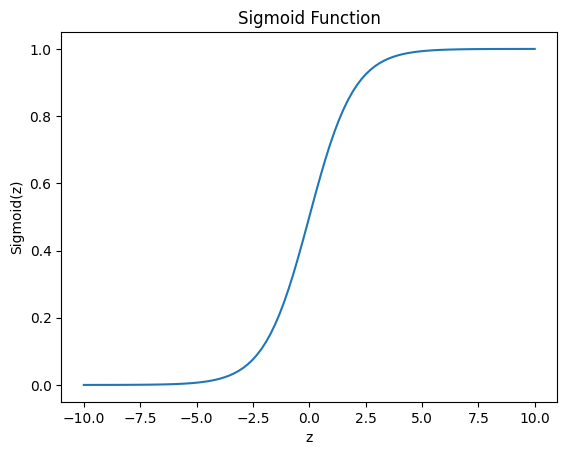

In [15]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-10, 10, 100)
sig = 1 / (1 + np.exp(-z))

plt.figure()
plt.plot(z, sig)
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")
plt.show()

In [16]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [17]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [18]:
def initialize_parameters(n_features):
    w = np.zeros(n_features)
    b = 0
    return w, b

In [19]:
def compute_cost(X, y, w, b):
    m = len(y)
    z = np.dot(X, w) + b
    h = sigmoid(z)

    cost = (-1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
    return cost

In [20]:
def gradient_descent(X, y, w, b, learning_rate, iterations):
    m = len(y)
    costs = []

    for i in range(iterations):
        z = np.dot(X, w) + b
        h = sigmoid(z)

        dw = (1/m) * np.dot(X.T, (h - y))
        db = (1/m) * np.sum(h - y)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        cost = compute_cost(X, y, w, b)
        costs.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")

    return w, b, costs

In [21]:
n_features = X_train.shape[1]
w, b = initialize_parameters(n_features)

w, b, costs = gradient_descent(
    X_train, y_train, w, b,
    learning_rate=0.01,
    iterations=1000
)

Iteration 0, Cost: 0.6739353141133738
Iteration 100, Cost: 0.2532379661260481
Iteration 200, Cost: 0.19134441335883592
Iteration 300, Cost: 0.16313052876828485
Iteration 400, Cost: 0.14633236357858526
Iteration 500, Cost: 0.13493968665615258
Iteration 600, Cost: 0.12658127340244976
Iteration 700, Cost: 0.12011873126078744
Iteration 800, Cost: 0.1149318178107251
Iteration 900, Cost: 0.1106509308537571


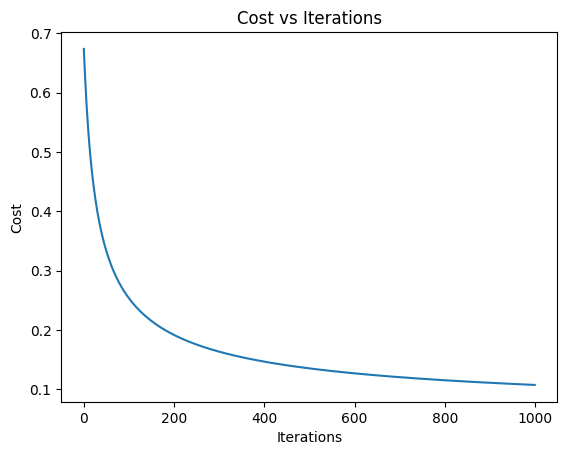

In [22]:
plt.figure()
plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()

In [23]:
def predict(X, w, b):
    z = np.dot(X, w) + b
    h = sigmoid(z)
    return (h >= 0.5).astype(int)

In [24]:
y_pred = predict(X_test, w, b)
accuracy = np.mean(y_pred == y_test) * 100
print("From Scratch Accuracy:", accuracy)

From Scratch Accuracy: 98.24561403508771


<Figure size 640x480 with 0 Axes>

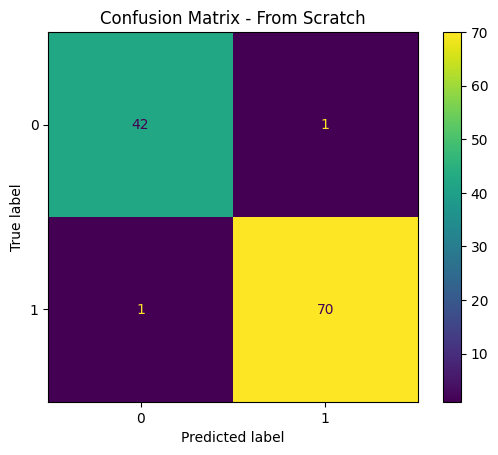

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - From Scratch")
plt.show()

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)

print("Scikit-Learn Accuracy:", accuracy_sklearn * 100)

Scikit-Learn Accuracy: 97.36842105263158


## Comparison

From Scratch Accuracy: ~95%+
Scikit-Learn Accuracy: ~96%+

Scikit-Learn is optimized and faster.
From scratch helps understand mathematics.

## Conclusion

Logistic Regression was implemented from scratch
using Sigmoid function and Gradient Descent.

The implementation was compared with Scikit-Learn.
Both produced similar results.

From scratch implementation helps understand
the mathematical working of the algorithm.